# KaroSpace Pseudobulk DE Audit

This notebook reproduces the current KaroSpace pseudobulk cluster differential-expression behavior for one categorical contrast. It is meant as an independent audit notebook: the code below repeats the aggregation, PyDESeq2 fit, filtering, sorting, and diagnostic plots instead of calling `karospace.pseudobulk.compute_pseudobulk_group_de`.

Current KaroSpace automatic cluster DE behavior reproduced here:

- aggregate raw counts by `replicate` + `groupby` category;
- keep only replicates where both compared categories are present with enough cells;
- fit PyDESeq2 with design `~ _pb_replicate + _pb_group`;
- test `source` vs `reference`;
- recompute adjusted p-values using the selected correction method;
- keep genes with finite log2FC;
- apply `min_pct_expressed` as `% source >= threshold AND % reference >= threshold`;
- sort by adjusted p-value, raw p-value, absolute log2FC, then gene name.

Important: this paired design is appropriate when each biological replicate can contain both categories, for example cluster 0 vs cluster 1 within each mouse. It is not the right design for conditions where no replicate is present in both conditions, such as strain comparisons across different mice.

In [ ]:
# Parameters: edit this cell
H5AD_PATH = "/Users/bastien.herve/Downloads/RRMAP2_xenium_all_samples.cellcharter.companion.ready.with_metadata.rerun.h5ad"

# Same conceptual inputs as the CLI/API pseudobulk cluster DE path.
GROUPBY = "leiden_1"
REPLICATE = "mouse_id"
SOURCE = "0"       # category shown as positive log2FC
REFERENCE = "1"    # baseline category

# Counts and filtering.
COUNTS_LAYER = "counts"  # use None for adata.X
MIN_CELLS = 20
MIN_REPLICATES = 2
MIN_PCT_EXPRESSED = 0.1  # values >1 are interpreted as percentages, e.g. 10 -> 0.10

# DE settings.
P_ADJUST_METHOD = "bonferroni"  # fdr_bh, bonferroni, holm, none
PADJ_CUTOFF = 0.05
LOG2FC_CUTOFF = 1
DESEQ2_FIT_TYPE = "parametric"  # parametric or mean

# Diagnostic plot settings.
MAX_DIAGNOSTIC_GENES = 1000
MA_RAW_PVALUE_GREEN_CUTOFF = 0.05

In [2]:
import json
import re
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage
from scipy.spatial.distance import pdist, squareform

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

def normalize_pct_threshold(value):
    threshold = float(value or 0.0)
    if threshold > 1.0:
        threshold /= 100.0
    return min(max(threshold, 0.0), 1.0)

def adjust_pvalues(pvalues, method="fdr_bh"):
    method = str(method or "fdr_bh").strip().lower().replace("-", "_")
    p = np.asarray(pvalues, dtype=float)
    adjusted = np.full(p.shape, np.nan, dtype=float)
    finite = np.isfinite(p)
    if not finite.any():
        return adjusted
    vals = np.clip(p[finite], 0.0, 1.0)
    n = vals.size
    if method in {"none", "raw", "pvalue", "pvalues"}:
        out = vals
    elif method in {"bonferroni", "bonf"}:
        out = np.minimum(vals * n, 1.0)
    elif method in {"holm", "holm_bonferroni"}:
        order = np.argsort(vals)
        ranked = vals[order]
        holm = np.maximum.accumulate((n - np.arange(n)) * ranked)
        holm = np.minimum(holm, 1.0)
        out = np.empty_like(vals)
        out[order] = holm
    else:
        # Benjamini-Hochberg FDR, same logic as KaroSpace pseudobulk.py.
        order = np.argsort(vals)
        ranked = vals[order]
        bh = ranked * n / np.arange(1, n + 1)
        bh = np.minimum.accumulate(bh[::-1])[::-1]
        bh = np.minimum(bh, 1.0)
        out = np.empty_like(vals)
        out[order] = bh
    out[(out == 0) & np.isfinite(out)] = np.nextafter(0.0, 1.0)
    adjusted[finite] = out
    return adjusted

def to_dense_counts(matrix):
    if sp.issparse(matrix):
        matrix = matrix.toarray()
    counts = np.asarray(matrix, dtype=float)
    counts[~np.isfinite(counts)] = 0
    counts[counts < 0] = 0
    return np.rint(counts).astype(int)

def positive_fraction(matrix, mask, gene_indices):
    gene_indices = np.asarray(gene_indices, dtype=int)
    if not np.any(mask) or gene_indices.size == 0:
        return [np.nan] * gene_indices.size
    sub = matrix[mask][:, gene_indices]
    if sp.issparse(sub):
        return np.asarray((sub > 0).mean(axis=0)).ravel().astype(float)
    return np.mean(np.asarray(sub) > 0, axis=0).astype(float)

def format_p(value):
    value = float(value) if np.isfinite(value) else np.nan
    if not np.isfinite(value):
        return "nan"
    if 0 < value < 0.001:
        return f"{value:.2e}"
    return f"{value:.6g}"

In [3]:
adata = ad.read_h5ad(H5AD_PATH)
print(adata)

required_obs = [GROUPBY, REPLICATE]
missing = [col for col in required_obs if col not in adata.obs.columns]
if missing:
    raise KeyError(f"Missing obs columns: {missing}")

if COUNTS_LAYER and COUNTS_LAYER not in adata.layers:
    warnings.warn(f"COUNTS_LAYER={COUNTS_LAYER!r} not found; falling back to adata.X")
    count_matrix_raw = adata.X
    counts_layer_used = "X"
elif COUNTS_LAYER:
    count_matrix_raw = adata.layers[COUNTS_LAYER]
    counts_layer_used = COUNTS_LAYER
else:
    count_matrix_raw = adata.X
    counts_layer_used = "X"

count_matrix = count_matrix_raw
print(f"Counts source: {counts_layer_used}")
print(f"Genes in AnnData: {adata.n_vars:,}")

AnnData object with n_obs × n_vars = 1713896 × 347
    obs: 'cell_id_old', 'x_centroid', 'y_centroid', 'Xenium_run', 'cell_id_new', 'inside_polygon', 'strain', 'mouse_id', 'region', 'class_label', 'class_name', 'class_bootstrapping_probability', 'subclass_label', 'subclass_name', 'subclass_bootstrapping_probability', 'supertype_label', 'supertype_name', 'supertype_bootstrapping_probability', 'cluster_label', 'cluster_name', 'cluster_alias', 'cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'is_it_doublet', 'Batch', 'Slide', 'class_name_high_prob', 'subclass_name_high_prob', 'leiden_1', 'major_celltype', 'final_celltype_annotation', 'final_celltype_annotation_v2', 'is_low_quality', 'final_celltype_annotation_v3'
    var: 'n_cells_by_cou

In [4]:
# Build valid cells and category values exactly like the KaroSpace pseudobulk path.
group_col = adata.obs[GROUPBY]
if pd.api.types.is_numeric_dtype(group_col):
    raise TypeError(f"GROUPBY={GROUPBY!r} is numeric; pseudobulk DE expects a categorical annotation")
if not isinstance(group_col.dtype, pd.CategoricalDtype):
    group_col = group_col.astype("category")

categories = [str(cat) for cat in group_col.cat.categories]
print(f"{GROUPBY}: {len(categories)} categories")
print(categories[:30])

if str(SOURCE) not in categories or str(REFERENCE) not in categories:
    raise ValueError(f"SOURCE={SOURCE!r} and REFERENCE={REFERENCE!r} must both be in categories")

rep_values = adata.obs[REPLICATE].astype(str)
group_values = group_col.astype(str)
valid = rep_values.notna().to_numpy() & group_values.notna().to_numpy()
valid &= np.asarray(group_col.cat.codes.to_numpy() >= 0, dtype=bool)

valid_indices = np.flatnonzero(valid)
rep_valid = rep_values.iloc[valid_indices].astype(str).to_numpy()
group_valid = group_values.iloc[valid_indices].astype(str).to_numpy()

sample_keys = []
sample_index = {}
rows = np.empty(valid_indices.size, dtype=np.int64)
for i, (rep, grp) in enumerate(zip(rep_valid, group_valid)):
    key = (str(rep), str(grp))
    idx = sample_index.get(key)
    if idx is None:
        idx = len(sample_keys)
        sample_index[key] = idx
        sample_keys.append(key)
    rows[i] = idx

incidence = sp.csr_matrix(
    (np.ones(valid_indices.size, dtype=np.float64), (rows, valid_indices)),
    shape=(len(sample_keys), adata.n_obs),
)
aggregate = to_dense_counts(incidence @ count_matrix)
cell_counts = np.bincount(rows, minlength=len(sample_keys)).astype(int)

pb_meta = pd.DataFrame(
    {
        "_pb_replicate": [key[0] for key in sample_keys],
        "_pb_group": [key[1] for key in sample_keys],
        "n_cells": cell_counts,
    },
    index=[f"pb_{i}" for i in range(len(sample_keys))],
)

display(pb_meta.head())
print(f"Pseudobulk samples: {len(pb_meta):,}")
print(f"Aggregate matrix: {aggregate.shape[0]:,} samples x {aggregate.shape[1]:,} genes")

leiden_1: 21 categories
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


,_pb_replicate,_pb_group,n_cells
pb_0,631317,0,3755
pb_1,631317,12,9320
pb_2,631317,17,6054
pb_3,631317,6,4648
pb_4,631317,1,3828


Pseudobulk samples: 588
Aggregate matrix: 588 samples x 347 genes


In [6]:
# Select the paired source/reference comparison.
source = str(SOURCE)
reference = str(REFERENCE)
min_cells = int(MIN_CELLS)
min_replicates = int(MIN_REPLICATES)

source_cell_mask = (group_values.to_numpy() == source) & valid
reference_cell_mask = (group_values.to_numpy() == reference) & valid
n_source = int(np.count_nonzero(source_cell_mask))
n_reference = int(np.count_nonzero(reference_cell_mask))

source_pb = pb_meta[(pb_meta["_pb_group"] == source) & (pb_meta["n_cells"] >= min_cells)]
reference_pb = pb_meta[(pb_meta["_pb_group"] == reference) & (pb_meta["n_cells"] >= min_cells)]
paired_reps = sorted(set(source_pb["_pb_replicate"]) & set(reference_pb["_pb_replicate"]))

print(f"Comparison: {source} vs {reference}")
print(f"Cells: {n_source:,} vs {n_reference:,}")
print(f"Paired replicates passing min_cells={min_cells}: {len(paired_reps):,}")

if n_source < min_cells or n_reference < min_cells:
    raise ValueError(f"Insufficient total cells: {n_source} vs {n_reference}; need >= {min_cells}")
if len(paired_reps) < min_replicates:
    raise ValueError(f"Insufficient paired replicates: {len(paired_reps)}; need >= {min_replicates}")

keep_mask = (
    pb_meta["_pb_replicate"].isin(paired_reps)
    & pb_meta["_pb_group"].isin([source, reference])
    & (pb_meta["n_cells"] >= min_cells)
)
keep_positions = np.flatnonzero(keep_mask.to_numpy())
pair_counts = aggregate[keep_positions]
pair_meta = pb_meta.iloc[keep_positions].copy()

print(
    f"{source} vs {reference}: {len(paired_reps)} paired replicates, "
    f"{pair_counts.shape[0]} pseudobulk samples, {pair_counts.shape[1]} genes"
)
display(pair_meta.sort_values(["_pb_replicate", "_pb_group"]).head(20))

Comparison: 0 vs 1
Cells: 126,354 vs 94,092
Paired replicates passing min_cells=20: 28
0 vs 1: 28 paired replicates, 56 pseudobulk samples, 347 genes


,_pb_replicate,_pb_group,n_cells
pb_75,261982,0,4099
pb_79,261982,1,3157
pb_537,264010,0,4496
pb_536,264010,1,3020
pb_267,264011,0,4358
pb_262,264011,1,3362
pb_23,311430,0,4546
pb_28,311430,1,3006
pb_450,350670,0,5042
pb_451,350670,1,2960


In [11]:
# Fit PyDESeq2. This mirrors KaroSpace's current paired design.
gene_names = [str(g) for g in adata.var_names]
counts_df = pd.DataFrame(pair_counts, index=pair_meta.index, columns=gene_names)
meta = pair_meta[["_pb_replicate", "_pb_group"]].copy()
meta["_pb_replicate"] = pd.Categorical(meta["_pb_replicate"])
meta["_pb_group"] = pd.Categorical(meta["_pb_group"], categories=[reference, source])

print(f"Design: ~ _pb_replicate + _pb_group")
print(f"Contrast: {source} vs {reference}")

try:
    dds = DeseqDataSet(
        counts=counts_df,
        metadata=meta,
        design="~ _pb_replicate + _pb_group",
        fit_type=DESEQ2_FIT_TYPE,
        quiet=True,
    )
except TypeError:
    # Compatibility with older PyDESeq2 APIs.
    dds = DeseqDataSet(
        counts=counts_df,
        clinical=meta,
        design_factors=["_pb_replicate", "_pb_group"],
        fit_type=DESEQ2_FIT_TYPE,
        refit_cooks=True,
        n_cpus=1,
    )

dds.deseq2()

try:
    stat_res = DeseqStats(dds, contrast=["_pb_group", source, reference], quiet=True)
except TypeError:
    stat_res = DeseqStats(dds, contrast=["_pb_group", source, reference], n_cpus=1)
stat_res.summary()
raw_results = stat_res.results_df.copy()

display(raw_results.head())
print(raw_results.shape)

Design: ~ _pb_replicate + _pb_group
Contrast: 0 vs 1


/Users/bastien.herve/miniconda3/envs/karospace-pseudobulk/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0610012G03Rik,662.191455,-0.015700,0.021262,-0.738413,4.602637e-01,4.825121e-01
2010300C02Rik,4110.889728,-0.101120,0.020187,-5.009244,5.464426e-07,7.292906e-07
4933402E13Rik,7.376496,-0.089211,0.151066,-0.590544,5.548257e-01,5.781518e-01
Acsbg1,369.119078,0.612575,0.040733,15.038689,4.095784e-51,9.938721e-51
Acta2,78.619789,-0.134511,0.065869,-2.042115,4.114016e-02,4.727031e-02


(347, 6)


In [12]:
# Format, filter, and sort exactly like KaroSpace.
work = raw_results.copy()
for col in ["baseMean", "log2FoldChange", "stat", "pvalue"]:
    if col not in work.columns:
        work[col] = np.nan

work["padj"] = adjust_pvalues(work["pvalue"].to_numpy(dtype=float), method=P_ADJUST_METHOD)
work["_gene"] = [str(idx) for idx in work.index]

n_before = len(work)
work = work[np.isfinite(work["log2FoldChange"].to_numpy(dtype=float))].copy()
n_finite_log2fc = len(work)

gene_to_idx = {str(g): i for i, g in enumerate(adata.var_names)}
gene_indices = [gene_to_idx.get(g) for g in work["_gene"]]
valid_positions = [i for i, idx in enumerate(gene_indices) if idx is not None]
if len(valid_positions) != len(gene_indices):
    work = work.iloc[valid_positions].copy()
    gene_indices = [gene_indices[i] for i in valid_positions]
n_in_var_names = len(work)

pct_source = positive_fraction(count_matrix, source_cell_mask, gene_indices)
pct_reference = positive_fraction(count_matrix, reference_cell_mask, gene_indices)
work["pct_source"] = pct_source
work["pct_reference"] = pct_reference

min_pct = normalize_pct_threshold(MIN_PCT_EXPRESSED)
if min_pct > 0:
    keep_pct = (work["pct_source"].fillna(0).to_numpy() >= min_pct) & (work["pct_reference"].fillna(0).to_numpy() >= min_pct)
    work = work.iloc[np.flatnonzero(keep_pct)].copy()
n_after_pct = len(work)

work["_padj_sort"] = work["padj"].fillna(np.inf)
work["_pvalue_sort"] = work["pvalue"].fillna(np.inf)
work["_abs_lfc"] = np.abs(work["log2FoldChange"].to_numpy(dtype=float))
work = work.sort_values(["_padj_sort", "_pvalue_sort", "_abs_lfc", "_gene"], ascending=[True, True, False, True])

de_table = work[["_gene", "baseMean", "log2FoldChange", "pvalue", "padj", "stat", "pct_source", "pct_reference"]].rename(
    columns={
        "_gene": "gene",
        "log2FoldChange": "log2fc",
        "stat": "score",
    }
).reset_index(drop=True)

print("Filtering audit")
print(f"  DESeq2 rows:              {n_before:,}")
print(f"  finite log2FC:            {n_finite_log2fc:,}")
print(f"  matched adata.var_names:  {n_in_var_names:,}")
print(f"  after min pct AND filter: {n_after_pct:,} (threshold={min_pct:.3f})")
print(f"  plotted/exported genes:   {len(de_table):,}")

display(de_table.head(30))

Filtering audit
  DESeq2 rows:              347
  finite log2FC:            347
  matched adata.var_names:  347
  after min pct AND filter: 139 (threshold=0.100)
  plotted/exported genes:   139


,gene,baseMean,log2fc,pvalue,padj,score,pct_source,pct_reference
0,Calb1,3072.391871,2.996656,0.000000e+00,4.940656e-324,73.889862,0.576309,0.131063
1,Rasgrf2,3832.614786,2.291212,0.000000e+00,4.940656e-324,73.631688,0.640795,0.240392
2,Hs3st2,1500.543343,-2.238903,0.000000e+00,4.940656e-324,-67.480717,0.107420,0.408919
3,Cux2,2123.322067,2.066480,0.000000e+00,4.940656e-324,45.372473,0.502873,0.136037
4,Lamp5,4699.813841,1.910361,0.000000e+00,4.940656e-324,104.071101,0.724441,0.290577
5,Mapk4,1434.778109,1.677511,0.000000e+00,4.940656e-324,55.868841,0.383209,0.153403
6,Pde7b,1383.887845,1.586925,0.000000e+00,4.940656e-324,46.246193,0.384998,0.146399
7,S100b,2117.429970,-1.552301,0.000000e+00,4.940656e-324,-49.598635,0.227860,0.414807
8,Meis2,1438.373320,1.458458,0.000000e+00,4.940656e-324,42.210784,0.314909,0.144603
9,Prr16,1154.957513,1.451873,0.000000e+00,4.940656e-324,49.493193,0.323179,0.140224


In [13]:
# Threshold summaries matching the viewer logic.
padj_cutoff = float(PADJ_CUTOFF)
log2fc_cutoff = float(LOG2FC_CUTOFF)
volcano_pass = (de_table["padj"] <= padj_cutoff) & (de_table["log2fc"].abs() >= log2fc_cutoff)
ma_green = de_table["pvalue"] < float(MA_RAW_PVALUE_GREEN_CUTOFF)

print(f"MA green genes, raw p < {MA_RAW_PVALUE_GREEN_CUTOFF}: {int(ma_green.sum()):,} / {len(de_table):,}")
print(f"Volcano/table passing genes, padj <= {padj_cutoff} and |log2FC| >= {log2fc_cutoff}: {int(volcano_pass.sum()):,} / {len(de_table):,}")
print(f"  positive/source-colored: {int((volcano_pass & (de_table['log2fc'] > 0)).sum()):,}")
print(f"  negative/reference-colored: {int((volcano_pass & (de_table['log2fc'] < 0)).sum()):,}")

display(de_table.loc[volcano_pass].head(50))

MA green genes, raw p < 0.05: 133 / 139
Volcano/table passing genes, padj <= 0.05 and |log2FC| >= 1.0: 24 / 139
  positive/source-colored: 20
  negative/reference-colored: 4


,gene,baseMean,log2fc,pvalue,padj,score,pct_source,pct_reference
0,Calb1,3072.391871,2.996656,0.000000e+00,4.940656e-324,73.889862,0.576309,0.131063
1,Rasgrf2,3832.614786,2.291212,0.000000e+00,4.940656e-324,73.631688,0.640795,0.240392
2,Hs3st2,1500.543343,-2.238903,0.000000e+00,4.940656e-324,-67.480717,0.107420,0.408919
3,Cux2,2123.322067,2.066480,0.000000e+00,4.940656e-324,45.372473,0.502873,0.136037
4,Lamp5,4699.813841,1.910361,0.000000e+00,4.940656e-324,104.071101,0.724441,0.290577
5,Mapk4,1434.778109,1.677511,0.000000e+00,4.940656e-324,55.868841,0.383209,0.153403
6,Pde7b,1383.887845,1.586925,0.000000e+00,4.940656e-324,46.246193,0.384998,0.146399
7,S100b,2117.429970,-1.552301,0.000000e+00,4.940656e-324,-49.598635,0.227860,0.414807
8,Meis2,1438.373320,1.458458,0.000000e+00,4.940656e-324,42.210784,0.314909,0.144603
9,Prr16,1154.957513,1.451873,0.000000e+00,4.940656e-324,49.493193,0.323179,0.140224


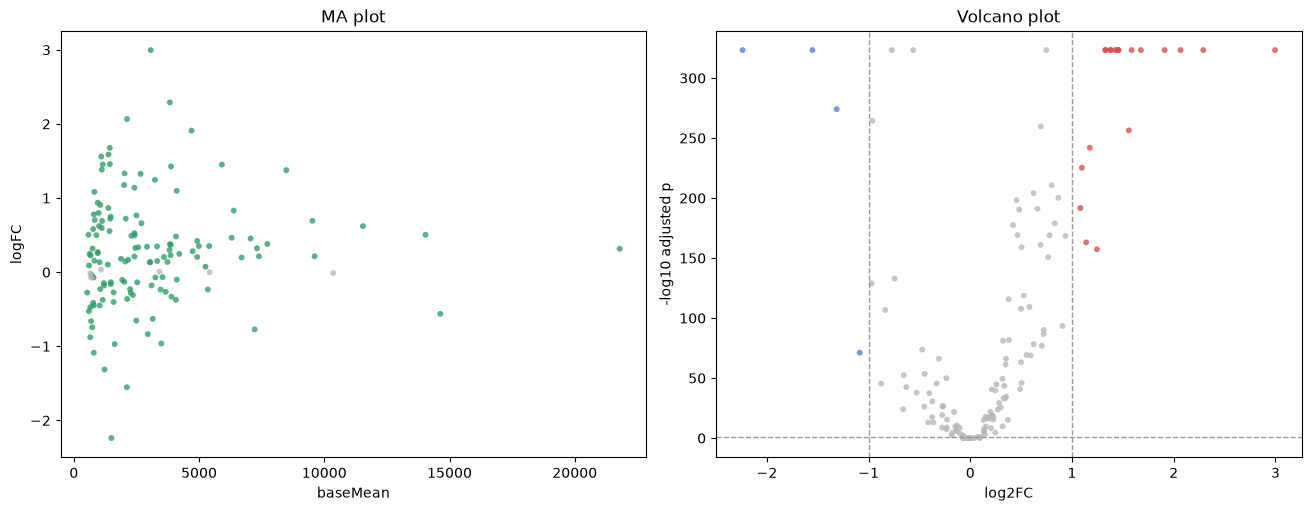

In [14]:
# MA and volcano plots.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax = axes[0]
colors_ma = np.where(ma_green, "#2f9e67", "#b8b8b8")
ax.scatter(de_table["baseMean"], de_table["log2fc"], c=colors_ma, s=18, alpha=0.8, linewidths=0)
ax.set_xlabel("baseMean")
ax.set_ylabel("logFC")
ax.set_title("MA plot")
ax.grid(False)

ax = axes[1]
safe_padj = de_table["padj"].fillna(1).clip(lower=np.nextafter(0.0, 1.0))
neg_log10_padj = -np.log10(safe_padj)
colors_volcano = np.full(len(de_table), "#b8b8b8", dtype=object)
colors_volcano[volcano_pass & (de_table["log2fc"] > 0)] = "#d94f4f"
colors_volcano[volcano_pass & (de_table["log2fc"] < 0)] = "#4f82d9"
ax.scatter(de_table["log2fc"], neg_log10_padj, c=colors_volcano, s=18, alpha=0.8, linewidths=0)
ax.axhline(-np.log10(max(padj_cutoff, np.nextafter(0.0, 1.0))), color="0.6", linestyle="--", linewidth=1)
ax.axvline(-log2fc_cutoff, color="0.6", linestyle="--", linewidth=1)
ax.axvline(log2fc_cutoff, color="0.6", linestyle="--", linewidth=1)
ax.set_xlabel("log2FC")
ax.set_ylabel("-log10 adjusted p")
ax.set_title("Volcano plot")

plt.show()

,_pb_replicate,_pb_group,n_cells,library_size,PC1,PC2
pb_0,631317,0,3755,537253,-7.710597,0.315128
pb_4,631317,1,3828,560703,8.551426,1.339265
pb_23,311430,0,4546,714939,-8.779633,1.377962
pb_28,311430,1,3006,452012,8.098772,1.720509
pb_51,600600,0,4305,562957,-7.552122,0.172169
pb_53,600600,1,2953,379176,8.084247,1.424188
pb_75,261982,0,4099,518548,-8.078491,0.007131
pb_79,261982,1,3157,336444,8.290460,-0.234338
pb_96,730346,1,3112,413510,8.158831,2.104283
pb_102,730346,0,4528,664479,-8.254242,2.093672


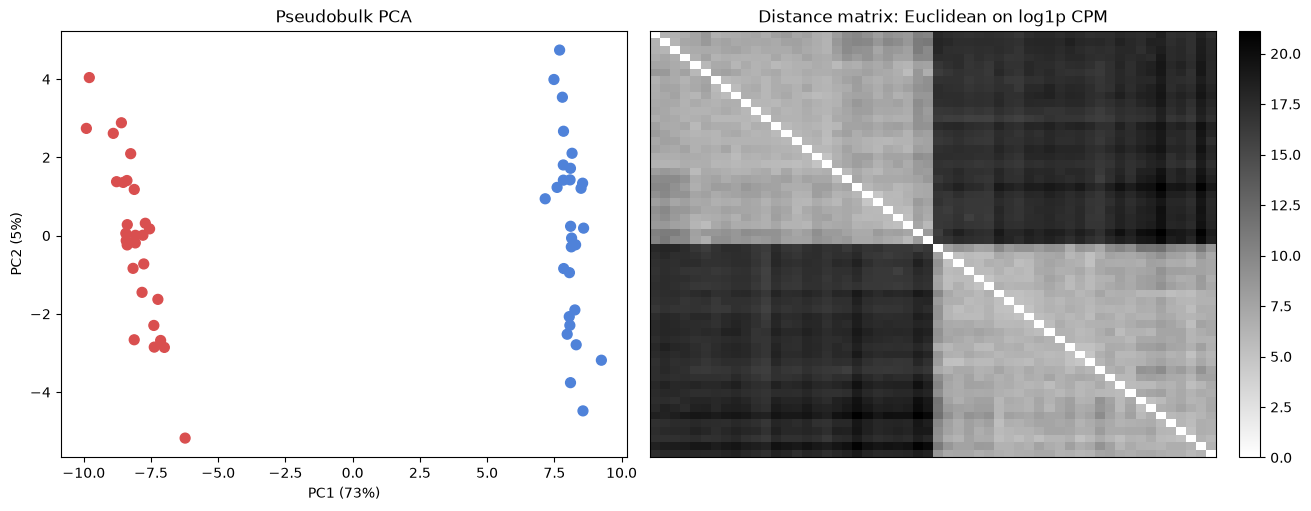

In [15]:
# PCA and distance matrix diagnostics matching KaroSpace's log1p CPM preprocessing.
counts = np.array(pair_counts, dtype=float, copy=True)
counts[~np.isfinite(counts)] = 0
counts[counts < 0] = 0
library_sizes = counts.sum(axis=1)
safe_libs = np.where(library_sizes > 0, library_sizes, 1.0)
log_cpm = np.log1p((counts / safe_libs[:, None]) * 1_000_000.0)

variances = np.var(log_cpm, axis=0)
finite_var = np.isfinite(variances) & (variances > 0)
feature_idx = np.flatnonzero(finite_var) if finite_var.any() else np.arange(log_cpm.shape[1])
if feature_idx.size > int(MAX_DIAGNOSTIC_GENES):
    order = np.argsort(variances[feature_idx])[::-1][: int(MAX_DIAGNOSTIC_GENES)]
    feature_idx = feature_idx[order]

diag_matrix = log_cpm[:, feature_idx]
diag_matrix = diag_matrix - np.nanmean(diag_matrix, axis=0, keepdims=True)
diag_matrix[~np.isfinite(diag_matrix)] = 0

u, s, vt = np.linalg.svd(diag_matrix, full_matrices=False)
scores = u[:, :2] * s[:2]
if scores.shape[1] == 1:
    scores = np.column_stack([scores[:, 0], np.zeros(scores.shape[0])])
eig = s ** 2
var_explained = eig / eig.sum() if eig.sum() > 0 else np.array([np.nan, np.nan])

condensed = pdist(diag_matrix, metric="euclidean")
dist = squareform(condensed)
leaf_order = leaves_list(linkage(condensed, method="average")).astype(int).tolist() if condensed.size else list(range(counts.shape[0]))
ordered_dist = dist[np.ix_(leaf_order, leaf_order)]

diag_info = pair_meta.copy()
diag_info["library_size"] = library_sizes.astype(int)
diag_info["PC1"] = scores[:, 0]
diag_info["PC2"] = scores[:, 1]
display(diag_info.head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
group_color = {source: "#d94f4f", reference: "#4f82d9"}
point_colors = [group_color.get(g, "#999999") for g in pair_meta["_pb_group"]]

axes[0].scatter(scores[:, 0], scores[:, 1], c=point_colors, s=50)
axes[0].set_xlabel(f"PC1 ({var_explained[0] * 100:.0f}%)" if np.isfinite(var_explained[0]) else "PC1")
axes[0].set_ylabel(f"PC2 ({var_explained[1] * 100:.0f}%)" if len(var_explained) > 1 and np.isfinite(var_explained[1]) else "PC2")
axes[0].set_title("Pseudobulk PCA")

im = axes[1].imshow(ordered_dist, cmap="gray_r", aspect="auto")
axes[1].set_title("Distance matrix: Euclidean on log1p CPM")
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.show()

In [ ]:
# Optional: compare against the DE result embedded in a KaroSpace HTML file.
html_path = Path(HTML_PATH) if HTML_PATH else None
if html_path and html_path.exists():
    html_text = html_path.read_text(encoding="utf-8")
    match = re.search(r'<script id="karospace-data" type="application/json">(.*?)</script>', html_text, re.S)
    if not match:
        raise ValueError(f"Could not find embedded KaroSpace data JSON in {html_path}")
    embedded = json.loads(match.group(1))
    html_result = (((embedded.get("cluster_de") or {}).get(GROUPBY) or {}).get(source) or {}).get(reference)
    if not html_result:
        raise KeyError(f"No embedded cluster_de result for {GROUPBY}: {source} vs {reference}")

    html_de = pd.DataFrame({
        "gene": html_result.get("genes", []),
        "baseMean": html_result.get("base_mean", []),
        "log2fc": html_result.get("log2foldchanges", html_result.get("logfoldchanges", [])),
        "pvalue": html_result.get("pvals", []),
        "padj": html_result.get("pvals_adj", []),
        "score": html_result.get("scores", []),
        "pct_source": html_result.get("pct_source", []),
        "pct_reference": html_result.get("pct_reference", []),
    })
    merged = de_table.merge(html_de, on="gene", suffixes=("_notebook", "_html"), how="outer", indicator=True)
    print(f"Notebook genes: {len(de_table):,}")
    print(f"HTML genes:     {len(html_de):,}")
    print(merged["_merge"].value_counts())
    shared = merged[merged["_merge"] == "both"].copy()
    for col in ["baseMean", "log2fc", "pvalue", "padj", "score", "pct_source", "pct_reference"]:
        a = pd.to_numeric(shared[f"{col}_notebook"], errors="coerce")
        b = pd.to_numeric(shared[f"{col}_html"], errors="coerce")
        max_abs_diff = np.nanmax(np.abs(a - b)) if len(shared) else np.nan
        print(f"max |{col} notebook - html| = {max_abs_diff:.6g}")
    display(merged.head(30))
else:
    print("HTML_PATH is empty or does not exist; skipping HTML comparison.")

In [ ]:
# Save the audited result table.
out_csv = Path(H5AD_PATH).with_suffix(f".{GROUPBY}.{source}_vs_{reference}.pseudobulk_audit.csv")
de_table.to_csv(out_csv, index=False)
print(out_csv)